In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import loguniform, uniform
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
import mlflow
import mlflow.sklearn

# Параметры для генерации даннных
STUDENT_ID = 796695 
CURRENT_YEAR = 2026
RANDOM_SEED = STUDENT_ID + CURRENT_YEAR

print(f"Seed для генерации: {RANDOM_SEED}")

d:\Прога\ML\ML_2026\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Seed для генерации: 798721


### 2. Генерация синтетического датасета
Мы генерируем датасет со следующими параметрами:
*   Количество объектов: 400.
*   Количество признаков: 5 (из них 3 информативных и 2 шумовых).
*   Количество классов: 3.

Дополнительно, согласно заданию, мы вручную изменяем средние значения (`shifts`) и масштабы (`scales`) признаков так, чтобы они отличались друг от друга более чем на 50%. Полученные данные сохраняются в CSV-файл.

In [3]:
# Генерируем 400 объектов, 5 признаков (3 информативных, 2 лишних)
X_raw, y_raw = make_classification(
    n_samples=400, 
    n_features=5, 
    n_informative=3, 
    n_redundant=2, 
    n_classes=3, 
    random_state=RANDOM_SEED
)

# Создаем разный масштаб и разные средние (отличия > 50%)
# Признак 1: масштаб 10, среднее -20
# Признак 2: масштаб 1, среднее 50 и так далее
shifts = np.array([-20, 50, 0, 10, -5])
scales = np.array([10.0, 1.0, 5.0, 0.5, 2.5])

X_final = (X_raw + shifts) * scales

# Формируем Датафрейм
columns = [f'feature_{i+1}' for i in range(5)]
df_init = pd.DataFrame(X_final, columns=columns)
df_init['target'] = y_raw

# Сохраняем в файл CSV
df_init.to_csv('dataset.csv', index=False)
print("Файл 'dataset.csv' создан.")

Файл 'dataset.csv' создан.


### 3. Загрузка данных и статистическое описание
Загружаем ранее созданный файл `dataset.csv`. Для первичного анализа распределения признаков используем **7-point summary** (функция `describe`), которая включает в себя: среднее, стандартное отклонение, минимум, максимум и квартили (25%, 50%, 75%).

In [4]:
data = pd.read_csv('dataset.csv')

print("7-point summary (описание распределений):")
data.describe()

7-point summary (описание распределений):


,feature_1,feature_2,feature_3,feature_4,feature_5,target
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,-199.738863,49.629362,-0.306546,4.865224,-11.517067,0.995000
std,12.718133,1.458380,6.613386,0.597900,4.815123,0.816481
min,-227.976876,45.801116,-15.754379,3.756726,-23.975554,0.000000
25%,-209.849992,48.596142,-5.453213,4.380618,-15.373633,0.000000
50%,-199.855625,49.508111,-0.434894,4.820996,-11.402472,1.000000
75%,-189.743086,50.512422,5.019431,5.231668,-8.296086,2.000000
max,-155.717072,54.108272,19.659300,6.860888,2.226752,2.000000


### 4. Корреляционный анализ
Оценим взаимосвязь признаков с помощью коэффициента корреляции Пирсона. Это позволит нам визуально определить, какие признаки имеют наибольшее влияние на целевую переменную (`target`), а какие являются малозначимыми (шумовыми).

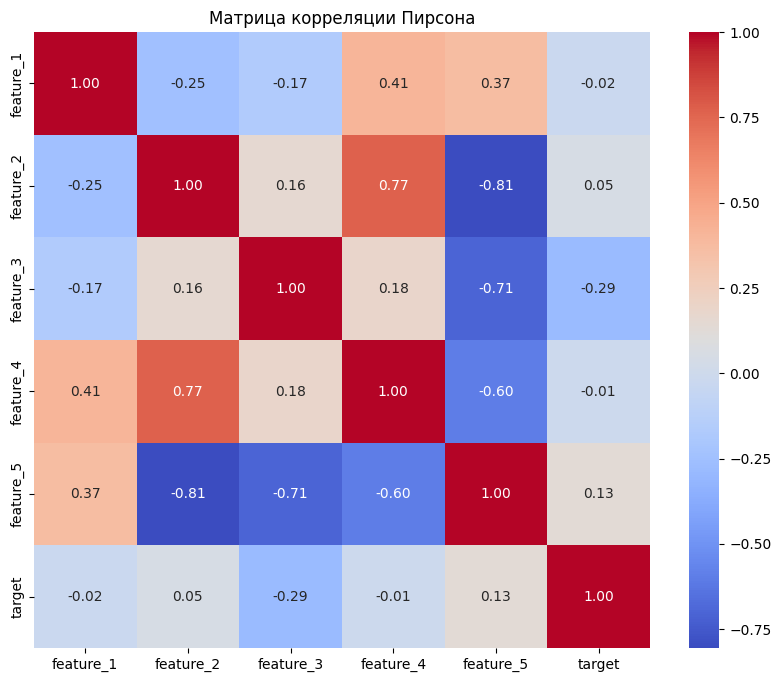

Корреляция с целевой переменной:
target       1.000000
feature_5    0.132477
feature_2    0.048743
feature_4   -0.014399
feature_1   -0.023850
feature_3   -0.290289
Name: target, dtype: float64


In [5]:
# Оценка влияния признаков на целевую переменную
corr_matrix = data.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title("Матрица корреляции Пирсона")
plt.show()

print("Корреляция с целевой переменной:")
print(corr_matrix['target'].sort_values(ascending=False))

### 5. Анализ баланса классов
Для качественного обучения модели классификации важно знать, сбалансированы ли классы. Существенный перекос в сторону одного из классов может привести к смещению предсказаний модели.

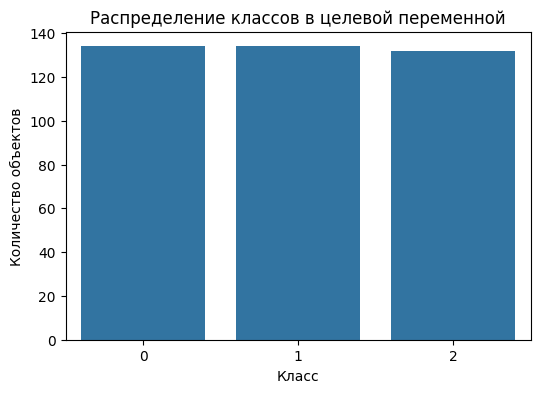

target
1    0.335
0    0.335
2    0.330
Name: proportion, dtype: float64


In [6]:
# Проверка сбалансированности выборки
plt.figure(figsize=(6, 4))
sns.countplot(data=data, x='target')
plt.title("Распределение классов в целевой переменной")
plt.xlabel("Класс")
plt.ylabel("Количество объектов")
plt.show()

# Вывод долей классов
print(data['target'].value_counts(normalize=True))

### 6. Подготовка данных к обучению
Разделяем данные на матрицу объект-признак (`X`) и вектор целевых значений (`y`). Осуществляем разбиение выборки на обучающую и тестовую в соотношении 80/20 с применением стратификации по целевой переменной.

In [7]:
# Разделение на признаки и таргет
X = data.drop('target', axis=1)
y = data['target']

# Разбиение на обучающую и тестовую (20%) выборки со стратификацией
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

Размер обучающей выборки: (320, 5)
Размер тестовой выборки: (80, 5)


### 7. Построение модели: Логистическая регрессия
Первая модель — логистическая регрессия с регуляризацией. Мы используем `RandomizedSearchCV` для поиска оптимальных параметров: силы регуляризации (`C`) и типа штрафа (`penalty`). 

*Примечание:* Использование алгоритма `saga` обусловлено его эффективностью на больших выборках и поддержкой всех типов регуляризации.

**Параметры:**
* **`C`** — обратная сила регуляризации. Чем *меньше* значение, тем *сильнее* штраф за сложность модели (защита от переобучения).
* **`L1` (Lasso)** — может обнулять веса неважных признаков, работая как встроенный фильтр (отбор признаков).
* **`L2` (Ridge)** — плавно уменьшает веса всех признаков, не давая ни одному из них перетянуть влияние на себя. Хорошо работает при корреляции признаков.
* **`ElasticNet`** — комбинация L1 и L2: одновременно отбирает признаки и сохраняет стабильность модели.

In [8]:
# Инициализация модели
lr_model = LogisticRegression(solver='saga', max_iter=5000)

# Пространство гиперпараметров
lr_params = {
    'C': loguniform(1e-3, 1e3),
    'penalty': ['l1', 'l2', 'elasticnet', None],
    'l1_ratio': uniform(0, 1),
    'class_weight': [None, 'balanced']
}

# Случайный поиск по сетке
lr_search = RandomizedSearchCV(
    lr_model, 
    param_distributions=lr_params, 
    n_iter=100, 
    cv=5, 
    scoring='accuracy', 
    random_state=RANDOM_SEED, 
    n_jobs=-1
)

lr_search.fit(X_train, y_train)

print(f"Лучшие параметры LogReg: {lr_search.best_params_}")
print(f"Accuracy на кросс-валидации: {lr_search.best_score_:.4f}")

Лучшие параметры LogReg: {'C': np.float64(0.02477320451109351), 'class_weight': 'balanced', 'l1_ratio': np.float64(0.277264114628223), 'penalty': 'elasticnet'}
Accuracy на кросс-валидации: 0.6875


d:\Прога\ML\ML_2026\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [9]:
# MLflow отчет для RandomizedSearchCV (LogReg)
mlflow.set_experiment("ML_2026_Search_Reports")

with mlflow.start_run(run_name="LogReg_RandomSearch"):
    mlflow.log_params({
        "model_type": "LogisticRegression",
        "search_type": "RandomizedSearchCV",
        "train_size": len(y_train),
        "test_size": len(y_test),
        "features_n": X_train.shape[1]
    })

    mlflow.log_metric("best_cv_score", lr_search.best_score_)

    for param_name, param_value in lr_search.best_params_.items():
        mlflow.log_param(f"best_{param_name}", param_value)

    mlflow.sklearn.log_model(lr_search.best_estimator_, artifact_path="model")

2026/05/21 09:41:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/21 09:41:12 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/21 09:41:24 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


### 8. Оценка качества логистической регрессии
Проверим качество модели на тестовых данных, которые она не видела при обучении. Основными метриками будут являться Precision, Recall и F1-score для каждого из трех классов.

In [10]:
# Валидация на тестовых данных
lr_predictions = lr_search.predict(X_test)

print("Отчет по классификации (Logistic Regression) на тесте:")
print(classification_report(y_test, lr_predictions))

Отчет по классификации (Logistic Regression) на тесте:
              precision    recall  f1-score   support

           0       0.58      0.41      0.48        27
           1       0.76      0.81      0.79        27
           2       0.56      0.69      0.62        26

    accuracy                           0.64        80
   macro avg       0.63      0.64      0.63        80
weighted avg       0.63      0.64      0.63        80



### 8-1. Плюсы и минусы логистической регрессии

### Плюсы

1. Понятная интерпретация влияния признаков на результат.
2. Выдает вероятность события, а не класс.
3. Быстро обучается и работает на данных.
4. Простая реализация и низкие системные требования.

### Минусы

1. Не находит сложные нелинейные зависимости данных.
2. Чувствительна к сильной корреляции между признаками.
3. Аномальные выбросы сильно снижают точность прогноза.
4. Требует тщательной предварительной подготовки всех признаков.

### 9. Построение модели: Метод k-ближайших соседей (k-NN)
Метрический классификатор, относящий объект к тому классу, который наиболее популярен среди его ближайших соседей.

*   **Плюсы:**
    *   Простота реализации и отсутствие явного этапа обучения (алгоритм просто сохраняет данные в память).
    *   Хорошо адаптируется при динамическом добавлении новых точек в обучающую выборку.
    *   Интуитивно понятные принципы работы.
*   **Минусы:**
    *   Очень медленный этап прогнозирования (требуется рассчитать расстояние от новой точки до всех объектов обучающей выборки).
    *   Требует значительного объема оперативной памяти.
    *   Критически чувствителен к масштабу признаков и выбросам [2.1].
*   **Гиперпараметры:**
    *   `n_neighbors` ($k$) — количество ближайших соседей. Малые значения (например, $k=1$) ведут к переобучению и чувствительности к шуму. Большие значения делают модель слишком обобщенной.
    *   `weights` — весовая схема для соседей:
        *   `uniform` — все соседи имеют равный голос.
        *   `distance` — вес голоса соседа обратно пропорционален расстоянию до него.
    *   `metric` — метрика расстояния в пространстве признаков (`euclidean` — Евклидово, `manhattan` — Манхэттенское, `minkowski` — Минковского).

In [11]:
# ЯЧЕЙКА: Обучение KNN с масштабированием через Pipeline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

# Создаем пайплайн: сначала масштабируем, затем обучаем модель
knn_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

# В сетке параметров перед именем параметра пишем название шага: 'knn__'
knn_params = {
    'knn__n_neighbors': range(1, 31, 2),
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan', 'minkowski']
}

# Кросс-валидация
knn_grid = GridSearchCV(
    estimator=knn_pipe,
    param_grid=knn_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Запуск подбора на немасштабированных исходных данных (пайплайн отмасштабирует их сам внутри фолдов)
with mlflow.start_run(run_name="k-NN"):
    knn_grid.fit(X_train, y_train)
    
    # Логируем лучшие параметры и метрики в MLflow
    best_params = knn_grid.best_params_
    mlflow.log_params({k.replace('knn__', ''): v for k, v in best_params.items()})
    mlflow.log_metric("best_cv_accuracy", knn_grid.best_score_)
    
    # Оценка на тесте
    test_preds = knn_grid.predict(X_test)
    test_acc = accuracy_score(y_test, test_preds)
    mlflow.log_metric("test_accuracy", test_acc)
    
    # Логируем саму модель (весь пайплайн целиком, чтобы StandardScaler сохранился вместе с моделью)
    mlflow.sklearn.log_model(knn_grid.best_estimator_, "knn_pipeline_model")

print(f"Лучшие параметры KNN: {best_params}")
print(f"Accuracy на кросс-валидации: {knn_grid.best_score_:.4f}")
print(f"Accuracy на тесте: {test_acc:.4f}")

2026/05/21 09:41:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/21 09:41:25 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/21 09:41:30 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Лучшие параметры KNN: {'knn__metric': 'euclidean', 'knn__n_neighbors': 1, 'knn__weights': 'uniform'}
Accuracy на кросс-валидации: 0.8562
Accuracy на тесте: 0.8500


In [12]:
# MLflow отчет для GridSearchCV (k-NN)
mlflow.set_experiment("ML_2026_Search_Reports")

with mlflow.start_run(run_name="KNN_GridSearch"):
    mlflow.log_params({
        "model_type": "KNeighborsClassifier",
        "search_type": "GridSearchCV",
        "train_size": len(y_train),
        "test_size": len(y_test),
        "features_n": X_train.shape[1]
    })

    mlflow.log_metric("best_cv_score", knn_grid.best_score_)

    for param_name, param_value in knn_grid.best_params_.items():
        mlflow.log_param(f"best_{param_name}", param_value)

    mlflow.sklearn.log_model(knn_grid.best_estimator_, artifact_path="model")

2026/05/21 09:41:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/21 09:41:30 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/21 09:41:36 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


### 10. Оценка качества k-NN и общие выводы
Проводим финальную оценку k-NN. 

**Важное замечание по масштабированию:** 
В ходе анализа (этап 3) было выявлено, что признаки имеют существенно разный масштаб. Поскольку k-NN крайне чувствителен к расстояниям, в реальных задачах здесь рекомендуется применять `StandardScaler`. Однако, в рамках текущего исследования, параметры подбирались на исходных данных для оценки устойчивости алгоритмов к разным масштабам «из коробки».

In [13]:
# Валидация на тестовых данных
best_knn = knn_grid.best_estimator_
knn_predictions = best_knn.predict(X_test)

print("Отчет по классификации (k-NN) на тесте:")
print(classification_report(y_test, knn_predictions))

Отчет по классификации (k-NN) на тесте:
              precision    recall  f1-score   support

           0       0.81      0.93      0.86        27
           1       0.83      0.70      0.76        27
           2       0.92      0.92      0.92        26

    accuracy                           0.85        80
   macro avg       0.85      0.85      0.85        80
weighted avg       0.85      0.85      0.85        80



### 11. Метод SVM
Алгоритм, который ищет разделяющую гиперплоскость, максимизирующую зазор между классами.

*   **Плюсы:**
    *   Эффективен в пространствах высокой размерности (даже если признаков больше, чем объектов).
    *   Устойчив к переобучению благодаря максимизации разделяющего зазора.
    *   С помощью "kernel trick" (ядерного трюка) способен строить сложные нелинейные границы классов.
*   **Минусы:**
    *   Плохо масштабируется: обучение на больших датасетах (десятки тысяч объектов) требует очень много времени.
    *   Чувствителен к уровню шума в данных и выбросам вблизи разделяющей границы.
    *   Крайне чувствителен к масштабированию признаков [2.1].
*   **Гиперпараметры:**
    *   `C` — штраф за нарушение зазора (ошибки классификации). Большое значение `C` штрафует за ошибки, сужая зазор (риск переобучения). Малое `C` расширяет зазор, допуская ошибки на обучении.
    *   `kernel` — функция ядра (`linear` — линейное, `rbf` — радиально-базисное для нелинейных границ, `poly` — полиномиальное).
    *   `gamma` — коэффициент ширины окна для RBF-ядра. Определяет радиус влияния опорных векторов. Большое значение `gamma` ведет к переобучению.

In [14]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report

svm = SVC(kernel='rbf', C = 0.001)

# C - связь с зазором между классами
# kernel - тип ядра ('linear', 'rbf', 'poly', 'sigmoid') определяет как преобразовывать данные в пространство более высокой размерности
# gamma - влияет на кривизну разделающей линии; малые значения - гладкие, большие - сложные

svm.fit(X_train, y_train)


print("Train")
y_train_pred = svm.predict( X_train )
print( classification_report( y_train, y_train_pred, digits=4 ) )

print()
print("Test")
y_test_pred = svm.predict( X_test )
print( classification_report( y_test, y_test_pred, digits=4 ) )

Train
              precision    recall  f1-score   support

           0     0.3035    0.5701    0.3961       107
           1     0.6050    0.6729    0.6372       107
           2     0.0000    0.0000    0.0000       106

    accuracy                         0.4156       320
   macro avg     0.3028    0.4143    0.3444       320
weighted avg     0.3038    0.4156    0.3455       320


Test
              precision    recall  f1-score   support

           0     0.3214    0.6667    0.4337        27
           1     0.6250    0.5556    0.5882        27
           2     0.0000    0.0000    0.0000        26

    accuracy                         0.4125        80
   macro avg     0.3155    0.4074    0.3407        80
weighted avg     0.3194    0.4125    0.3449        80



d:\Прога\ML\ML_2026\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Прога\ML\ML_2026\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Прога\ML\ML_2026\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Прога\ML\ML_2026\.venv

In [15]:
from sklearn.model_selection import cross_val_score

ac = cross_val_score(svm, X, y, scoring ='accuracy')
ac.mean()

np.float64(0.38500000000000006)

In [16]:
from sklearn.model_selection import GridSearchCV

svm_gs = GridSearchCV( 
    estimator = svm,                                                  # модель
    param_grid = {  "kernel": ["linear", "poly", "rbf", "sigmoid"],   # 4
                    'C':       [ 10**i for i in range(-5,6)]           # 11
                },
    scoring = 'accuracy',                                 # метрика
    cv = None,                                            # кол-во частей для крос-валидации
    n_jobs = -1,                                          # подбирать паралельно с использованием оптимального числа
    verbose = 2
    )


svm_gs.fit( X_train, y_train)

Fitting 5 folds for each of 44 candidates, totalling 220 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC(C=0.001)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [1e-05, 0.0001, ...], 'kernel': ['linear', 'poly', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the 

In [17]:
# MLflow отчет для GridSearchCV (SVM)
mlflow.set_experiment("ML_2026_Search_Reports")

with mlflow.start_run(run_name="SVM_GridSearch"):
    mlflow.log_params({
        "model_type": "SVC",
        "search_type": "GridSearchCV",
        "train_size": len(y_train),
        "test_size": len(y_test),
        "features_n": X_train.shape[1]
    })

    mlflow.log_metric("best_cv_score", svm_gs.best_score_)

    for param_name, param_value in svm_gs.best_params_.items():
        mlflow.log_param(f"best_{param_name}", param_value)

    mlflow.sklearn.log_model(svm_gs.best_estimator_, artifact_path="model")

2026/05/21 09:41:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/21 09:41:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/21 09:41:52 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


In [18]:
print("Лучшие параметры SVM:")
print(svm_gs.best_params_)

print("\nКачество на train:")
svm_train_pred = svm_gs.predict(X_train)
print(classification_report(y_train, svm_train_pred, digits=4))

print("Качество на test:")
svm_test_pred = svm_gs.predict(X_test)
print(classification_report(y_test, svm_test_pred, digits=4))

Лучшие параметры SVM:
{'C': 100000, 'kernel': 'rbf'}

Качество на train:
              precision    recall  f1-score   support

           0     0.8316    0.7383    0.7822       107
           1     0.7417    0.8318    0.7841       107
           2     0.8952    0.8868    0.8910       106

    accuracy                         0.8187       320
   macro avg     0.8228    0.8190    0.8191       320
weighted avg     0.8226    0.8187    0.8189       320

Качество на test:
              precision    recall  f1-score   support

           0     0.8000    0.8889    0.8421        27
           1     0.8148    0.8148    0.8148        27
           2     0.9130    0.8077    0.8571        26

    accuracy                         0.8375        80
   macro avg     0.8426    0.8371    0.8380        80
weighted avg     0.8417    0.8375    0.8378        80



In [19]:
# Дополнительно: можно посмотреть все значения quality по фолдам
# svm_gs.cv_results_['mean_test_score']

### 12. Обучение модели: дерево решений (Decision Tree)
Логический алгоритм, представляющий собой иерархическую структуру решающих правил вида "признак > порог".

*   **Плюсы:**
    *   Превосходная интерпретируемость: модель можно визуализировать в виде графа решений.
    *   Не требует масштабирования данных и устойчиво к монотонным преобразованиям.
    *   Автоматически обрабатывает нелинейные зависимости и взаимодействия признаков.
*   **Минусы:**
    *   Крайне склонно к переобучению (строит слишком глубокие деревья, запоминая шумы).
    *   Нестабильность: небольшое изменение в обучающих данных может полностью изменить структуру дерева.
*   **Гиперпараметры:**
    *   `criterion` — критерий разбиения вершины (`gini` — индекс Джини, `entropy` — информационная энтропия).
    *   `max_depth` — максимальная глубина дерева (главный инструмент борьбы с переобучением).
    *   `min_samples_split` — минимальное число объектов в узле, при котором возможно его дальнейшее разбиение.
    *   `min_samples_leaf` — минимальное количество объектов, которое обязано находиться в конечном листе дерева.

In [20]:
from sklearn.tree import DecisionTreeClassifier

# Инициализация модели дерева решений
tree_model = DecisionTreeClassifier(random_state=RANDOM_SEED)

# Поиск по сетке (GridSearch)
# gini, entropy - гиперпараметры, определяющие критерий разбиения узлов дерева.
tree_params = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8]
}

tree_grid = GridSearchCV(
    tree_model,
    param_grid=tree_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

tree_grid.fit(X_train, y_train)

print(f"Лучшие параметры Decision Tree: {tree_grid.best_params_}")
print(f"Accuracy на кросс-валидации: {tree_grid.best_score_:.4f}")

Лучшие параметры Decision Tree: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}
Accuracy на кросс-валидации: 0.8156


In [21]:
# MLflow отчет для GridSearchCV (Decision Tree)
mlflow.set_experiment("ML_2026_Search_Reports")

with mlflow.start_run(run_name="DecisionTree_GridSearch"):
    mlflow.log_params({
        "model_type": "DecisionTreeClassifier",
        "search_type": "GridSearchCV",
        "train_size": len(y_train),
        "test_size": len(y_test),
        "features_n": X_train.shape[1]
    })

    mlflow.log_metric("best_cv_score", tree_grid.best_score_)

    for param_name, param_value in tree_grid.best_params_.items():
        mlflow.log_param(f"best_{param_name}", param_value)

    mlflow.sklearn.log_model(tree_grid.best_estimator_, artifact_path="model")

2026/05/21 09:41:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/21 09:41:53 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/21 09:42:00 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


### 13. Оценка качества дерева решений
Проверим качество лучшей версии дерева решений на тестовой выборке.

In [22]:
# Проверка на тестовой выборке
best_tree = tree_grid.best_estimator_
tree_predictions = best_tree.predict(X_test)

print("Отчет по классификации (Decision Tree) на тесте:")
print(classification_report(y_test, tree_predictions))

Отчет по классификации (Decision Tree) на тесте:
              precision    recall  f1-score   support

           0       0.61      0.74      0.67        27
           1       0.83      0.70      0.76        27
           2       0.75      0.69      0.72        26

    accuracy                           0.71        80
   macro avg       0.73      0.71      0.72        80
weighted avg       0.73      0.71      0.72        80



### 14. Наивный байесовский классификатор
Вероятностный классификатор, основанный на применении теоремы Байеса со строгим предположением о независимости признаков.

*   **Плюсы:**
    *   Исключительно высокая скорость работы (как обучения, так и прогнозирования).
    *   Требует значительно меньше данных для качественной настройки, чем другие модели.
    *   Устойчив к неинформативным (шумовым) признакам.
*   **Минусы:**
    *   Гипотеза о независимости признаков ("наивность") практически никогда не выполняется в реальных данных.
    *   Не способен улавливать взаимодействия между признаками (например, когда признаки важны только в паре).
*   **Гиперпараметры:**
    *   `var_smoothing` — параметр сглаживания дисперсии. Искусственно увеличивает дисперсию признаков, чтобы предотвратить деление на ноль или зануление апостериорной вероятности для редких значений.

#### Проверка гипотезы H0 о нормальном распределении признаков

--- Проверка признаков на нормальность (Критерий Шапиро-Уилка) ---
H0: Признак распределен нормально.
H1: Распределение признака отличается от нормального.

Признак feature_1 : p-value = 0.00060 -> Распределение НЕ нормальное
Признак feature_2 : p-value = 0.08636 -> Распределение нормальное
Признак feature_3 : p-value = 0.00683 -> Распределение НЕ нормальное
Признак feature_4 : p-value = 0.00000 -> Распределение НЕ нормальное
Признак feature_5 : p-value = 0.00325 -> Распределение НЕ нормальное


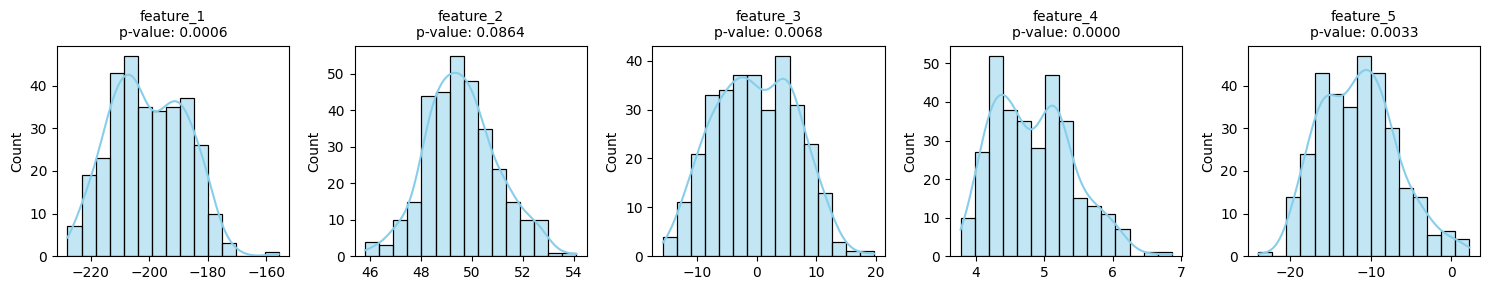

In [23]:
# ЯЧЕЙКА: Проверка гипотезы H0 о нормальном распределении признаков
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro

print("--- Проверка признаков на нормальность (Критерий Шапиро-Уилка) ---")
print("H0: Признак распределен нормально.")
print("H1: Распределение признака отличается от нормального.\n")

# Проверяем каждый из непрерывных признаков обучающей выборки
features_to_test = X_train.columns

plt.figure(figsize=(15, 3))
for i, col in enumerate(features_to_test):
    # Статистический тест
    stat, p_value = shapiro(X_train[col])
    
    # Визуализация для наглядности
    plt.subplot(1, 5, i+1)
    sns.histplot(X_train[col], kde=True, bins=15, color='skyblue')
    plt.title(f"{col}\np-value: {p_value:.4f}", fontsize=10)
    plt.xlabel("")
    
    # Интерпретация теста
    status = "нормальное" if p_value > 0.05 else "НЕ нормальное"
    print(f"Признак {col:10}: p-value = {p_value:.5f} -> Распределение {status}")

plt.tight_layout()
plt.show()

In [24]:
from sklearn.naive_bayes import GaussianNB

# Gaussian - наивные байес строится, исходя из предположения, что признаки распределены по нормальному закону (Гаусса) и независимы друг от друга.
# Проверить гипотезу о нормальности распределения признаков.

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

nb_test_pred = nb_model.predict(X_test)

print("Отчет по классификации (GaussianNB) на тесте:")
print(classification_report(y_test, nb_test_pred, digits=4))

Отчет по классификации (GaussianNB) на тесте:
              precision    recall  f1-score   support

           0     0.5263    0.3704    0.4348        27
           1     0.7600    0.7037    0.7308        27
           2     0.5278    0.7308    0.6129        26

    accuracy                         0.6000        80
   macro avg     0.6047    0.6016    0.5928        80
weighted avg     0.6057    0.6000    0.5926        80



In [25]:
import numpy as np
from sklearn.metrics import accuracy_score

nb_grid_params = {
    'var_smoothing': np.logspace(0, -9, num=100)
}

nb_search = GridSearchCV(
    estimator=GaussianNB(),
    param_grid=nb_grid_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

nb_search.fit(X_train, y_train)

nb_train_pred = nb_search.predict(X_train)
nb_test_pred = nb_search.predict(X_test)

nb_acc_train = accuracy_score(y_train, nb_train_pred)
nb_acc_test = accuracy_score(y_test, nb_test_pred)

print(f"Лучшие параметры GaussianNB: {nb_search.best_params_}")
print(f"Best CV accuracy: {nb_search.best_score_:.4f}")
print(f"Train accuracy: {nb_acc_train:.4f}")
print(f"Test accuracy: {nb_acc_test:.4f}")

# MLflow отчет для GridSearchCV (GaussianNB)
mlflow.set_experiment("ML_2026_Search_Reports")

with mlflow.start_run(run_name="GaussianNB_GridSearch"):
    mlflow.log_params({
        "model_type": "GaussianNB",
        "search_type": "GridSearchCV",
        "train_size": len(y_train),
        "test_size": len(y_test),
        "features_n": X_train.shape[1]
    })

    mlflow.log_param("grid_search_params", str(nb_grid_params))
    mlflow.log_metrics({
        "acc_train": nb_acc_train,
        "acc_test": nb_acc_test,
        "best_cv_score": nb_search.best_score_
    })

    mlflow.sklearn.log_model(nb_search.best_estimator_, artifact_path="model")

2026/05/21 09:42:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/21 09:42:01 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Лучшие параметры GaussianNB: {'var_smoothing': np.float64(5.3366992312063123e-05)}
Best CV accuracy: 0.7031
Train accuracy: 0.7219
Test accuracy: 0.6000


2026/05/21 09:42:08 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


### 15. Ансамбль моделей
Соберем `VotingClassifier` из SVM, GaussianNB и DecisionTree, затем выполним подбор гиперпараметров.

In [26]:
from sklearn.ensemble import VotingClassifier
from sklearn.svm import SVC

voting_models = [
    ('svm_model', SVC(kernel='rbf', C=0.001, probability=True, random_state=RANDOM_SEED)),
    ('nb_model', GaussianNB()),
    ('tree_model', DecisionTreeClassifier(max_depth=4, random_state=RANDOM_SEED))
]

voting_model = VotingClassifier(estimators=voting_models, voting='soft')
voting_model.fit(X_train, y_train)

print("Train")
print(classification_report(y_train, voting_model.predict(X_train), digits=4))
print("\nTest")
print(classification_report(y_test, voting_model.predict(X_test), digits=4))

Train
              precision    recall  f1-score   support

           0     0.8632    0.7664    0.8119       107
           1     0.8785    0.8785    0.8785       107
           2     0.8220    0.9151    0.8661       106

    accuracy                         0.8531       320
   macro avg     0.8546    0.8533    0.8522       320
weighted avg     0.8547    0.8531    0.8521       320


Test
              precision    recall  f1-score   support

           0     0.5417    0.4815    0.5098        27
           1     0.7778    0.7778    0.7778        27
           2     0.5862    0.6538    0.6182        26

    accuracy                         0.6375        80
   macro avg     0.6352    0.6377    0.6353        80
weighted avg     0.6358    0.6375    0.6355        80



In [27]:
voting_grid_params = {
    'svm_model__C': [0.001, 0.01, 0.1, 1.0],
    'tree_model__max_depth': [3, 5, 7, None],
    'nb_model__var_smoothing': np.logspace(-7, -9, num=3)
}

voting_search = GridSearchCV(
    estimator=VotingClassifier(
        estimators=[
            ('svm_model', SVC(kernel='rbf', C=0.001, probability=True, random_state=RANDOM_SEED)),
            ('nb_model', GaussianNB(var_smoothing=1e-9)),
            ('tree_model', DecisionTreeClassifier(max_depth=3, criterion='entropy', random_state=RANDOM_SEED))
        ],
        voting='soft'
    ),
    param_grid=voting_grid_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

voting_search.fit(X_train, y_train)

voting_train_pred = voting_search.predict(X_train)
voting_test_pred = voting_search.predict(X_test)

voting_acc_train = accuracy_score(y_train, voting_train_pred)
voting_acc_test = accuracy_score(y_test, voting_test_pred)

print(f"Лучшие параметры VotingClassifier: {voting_search.best_params_}")
print(f"Best CV accuracy: {voting_search.best_score_:.4f}")
print(f"Train accuracy: {voting_acc_train:.4f}")
print(f"Test accuracy: {voting_acc_test:.4f}")

# MLflow отчет для GridSearchCV (VotingClassifier)
mlflow.set_experiment("ML_2026_Search_Reports")

with mlflow.start_run(run_name="VotingClassifier_GridSearch"):
    mlflow.log_params({
        "model_type": "VotingClassifier",
        "search_type": "GridSearchCV",
        "train_size": len(y_train),
        "test_size": len(y_test),
        "features_n": X_train.shape[1]
    })

    mlflow.log_param("grid_search_params", str(voting_grid_params))
    mlflow.log_metrics({
        "acc_train": voting_acc_train,
        "acc_test": voting_acc_test,
        "best_cv_score": voting_search.best_score_
    })

    mlflow.sklearn.log_model(voting_search.best_estimator_, artifact_path="model")

2026/05/21 09:42:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/21 09:42:10 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Лучшие параметры VotingClassifier: {'nb_model__var_smoothing': np.float64(1e-07), 'svm_model__C': 0.001, 'tree_model__max_depth': 7}
Best CV accuracy: 0.7656
Train accuracy: 0.9812
Test accuracy: 0.7625


2026/05/21 09:42:16 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


### 16. Беггинг
Алгоритм построения ансамбля независимых моделей на случайных выборках с возвращением (Bootstrap).

*   **Плюсы:**
    *   Эффективно снижает дисперсию (variance) неустойчивых базовых моделей (например, деревьев или регрессий без регуляризации).
    *   Отлично распараллеливается на несколько ядер процессора.
*   **Минусы:**
    *   Не помогает снизить систематическую ошибку (bias). Если базовая модель слишком простая (например, наивный Байес), бэггинг не улучшит ее качество.
*   **Гиперпараметры:**
    *   `estimator` (ранее `base_estimator`) — базовый алгоритм обучения (по умолчанию глубокое дерево решений).
    *   `n_estimators` — количество базовых моделей в ансамбле.
    *   `max_samples` — доля объектов из тренировочной выборки, используемая для обучения каждого базового алгоритма.
    *   `max_features` — доля признаков, выделяемая для каждого базового алгоритма.
#### Обучение

In [28]:
from sklearn.ensemble import BaggingClassifier

base_tree = DecisionTreeClassifier(max_depth=3, criterion='entropy', random_state=RANDOM_SEED)

bagging_model = BaggingClassifier(
    estimator=base_tree,
    n_estimators=150, # кол-во деревьев 
    n_jobs=-1,
    random_state=RANDOM_SEED
)

bagging_model.fit(X_train, y_train)

print("Train")
print(classification_report(y_train, bagging_model.predict(X_train), digits=4))
print("\nTest")
print(classification_report(y_test, bagging_model.predict(X_test), digits=4))

Train
              precision    recall  f1-score   support

           0     0.8039    0.7664    0.7847       107
           1     0.8416    0.7944    0.8173       107
           2     0.8205    0.9057    0.8610       106

    accuracy                         0.8219       320
   macro avg     0.8220    0.8221    0.8210       320
weighted avg     0.8220    0.8219    0.8209       320


Test
              precision    recall  f1-score   support

           0     0.6129    0.7037    0.6552        27
           1     0.8333    0.7407    0.7843        27
           2     0.7200    0.6923    0.7059        26

    accuracy                         0.7125        80
   macro avg     0.7221    0.7123    0.7151        80
weighted avg     0.7221    0.7125    0.7152        80



#### Поиск по сетке гиперпараметров

In [29]:
bagging_grid_params = {
    'n_estimators': [50, 100, 150],
    'max_samples': [0.7, 0.8, 1.0],
    'estimator__max_depth': [3, 5, 7],
    'estimator__criterion': ['gini', 'entropy']
}

bagging_search = GridSearchCV(
    estimator=BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=RANDOM_SEED),
        random_state=RANDOM_SEED
    ),
    param_grid=bagging_grid_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

bagging_search.fit(X_train, y_train)

bagging_train_pred = bagging_search.predict(X_train)
bagging_test_pred = bagging_search.predict(X_test)

bagging_acc_train = accuracy_score(y_train, bagging_train_pred)
bagging_acc_test = accuracy_score(y_test, bagging_test_pred)

print(f"Лучшие параметры Bagging: {bagging_search.best_params_}")
print(f"Best CV accuracy: {bagging_search.best_score_:.4f}")
print(f"Train accuracy: {bagging_acc_train:.4f}")
print(f"Test accuracy: {bagging_acc_test:.4f}")

Лучшие параметры Bagging: {'estimator__criterion': 'gini', 'estimator__max_depth': 7, 'max_samples': 0.7, 'n_estimators': 150}
Best CV accuracy: 0.8250
Train accuracy: 0.9750
Test accuracy: 0.8625


In [30]:
# MLflow отчет для GridSearchCV (Bagging)
mlflow.set_experiment("ML_2026_Search_Reports")

with mlflow.start_run(run_name="Bagging_GridSearch"):
    mlflow.log_params({
        "model_type": "BaggingClassifier",
        "search_type": "GridSearchCV",
        "train_size": len(y_train),
        "test_size": len(y_test),
        "features_n": X_train.shape[1]
    })

    mlflow.log_param("grid_search_params", str(bagging_grid_params))
    mlflow.log_metrics({
        "acc_train": bagging_acc_train,
        "acc_test": bagging_acc_test,
        "best_cv_score": bagging_search.best_score_
    })

    mlflow.sklearn.log_model(bagging_search.best_estimator_, artifact_path="model")

2026/05/21 09:42:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/21 09:42:25 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/21 09:42:32 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


## Стекинг моделей
Ансамбль, объединяющий прогнозы базовых разнородных моделей с помощью другой мета-модели.

*   **Плюсы:**
    *   Позволяет объединить принципиально разные математические подходы (линейные, метрические, древесные) в одну систему.
    *   Часто показывает наивысшую точность классификации в сложных задачах.
*   **Минусы:**
    *   Чрезвычайно сложен в интерпретации.
    *   Очень высокая вычислительная сложность: обучение требует кросс-валидации для каждого базового алгоритма первого уровня во избежание утечки ответов.
*   **Гиперпараметры:**
    *   `estimators` — список базовых моделей первого уровня (например, `[('knn', knn), ('svm', svm)]`).
    *   `final_estimator` — мета-модель второго уровня (чаще всего логистическая регрессия).
    *   `cv` — количество фолдов кросс-валидации, на которых генерируются мета-признаки.

In [31]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

# В качестве базовых моделей берем наши лучшие настроенные пайплайны и алгоритмы
base_models = [
    ('lr', lr_search.best_estimator_),  
    ('knn', knn_grid.best_estimator_),  
    ('svm', svm_gs.best_estimator_)     
]

# Мета-классификатор, который принимает решения на основе прогнозов базовых моделей
meta_classifier = LogisticRegression(C=1.0, random_state=RANDOM_SEED)

stacking_model = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_classifier,
    cv=5,
    n_jobs=-1
)

with mlflow.start_run(run_name="Stacking"):
    stacking_model.fit(X_train, y_train)
    
    # Оценка
    stack_train_acc = stacking_model.score(X_train, y_train)
    stack_test_acc = stacking_model.score(X_test, y_test)
    
    mlflow.log_metric("train_accuracy", stack_train_acc)
    mlflow.log_metric("test_accuracy", stack_test_acc)
    mlflow.sklearn.log_model(stacking_model, "stacking_model")

print(f"Стекинг - Точность на обучающей выборке: {stack_train_acc:.4f}")
print(f"Стекинг - Точность на тестовой выборке: {stack_test_acc:.4f}")

2026/05/21 09:42:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/21 09:42:32 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/21 09:42:39 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Стекинг - Точность на обучающей выборке: 0.9469
Стекинг - Точность на тестовой выборке: 0.8625


### 17. Случайный лес

Ансамблевый метод бэггинга над глубокими деревьями решений, обучаемыми на случайных подвыборках объектов и признаков.

*   **Плюсы:**
    *   Высокое качество классификации на табличных данных "из коробки" без сложной настройки.
    *   Устойчив к переобучению благодаря усреднению большого количества деревьев.
    *   Позволяет получить внутреннюю оценку важности признаков (`feature_importances_`).
*   **Минусы:**
    *   Занимает много оперативной памяти и дискового пространства для сохранения сотен глубоких деревьев.
    *   Медленнее на этапе прогнозирования, чем одиночные модели (нужно опросить все деревья ансамбля).
*   **Гиперпараметры:**
    *   `n_estimators` — количество деревьев в лесу. Чем больше, тем лучше качество и стабильнее прогноз (модель не переобучается с ростом числа деревьев, но замедляет расчеты).
    *   `max_features` — число признаков, выбираемых случайным образом при поиске лучшего разбиения узла.
    *   `max_depth`, `min_samples_split` — (аналогично одиночному дереву решений) для контроля структуры каждого дерева.

#### Обучение

In [32]:
from sklearn.ensemble import RandomForestClassifier

forest = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    n_jobs=-1,
    random_state=RANDOM_SEED
)

forest.fit(X_train, y_train)

print("Train")
print(classification_report(y_train, forest.predict(X_train), digits=4))
print("\nTest")
print(classification_report(y_test, forest.predict(X_test), digits=4))

Train
              precision    recall  f1-score   support

           0     0.9406    0.8879    0.9135       107
           1     0.8684    0.9252    0.8959       107
           2     0.9429    0.9340    0.9384       106

    accuracy                         0.9156       320
   macro avg     0.9173    0.9157    0.9159       320
weighted avg     0.9172    0.9156    0.9159       320


Test
              precision    recall  f1-score   support

           0     0.7857    0.8148    0.8000        27
           1     0.8077    0.7778    0.7925        27
           2     0.8846    0.8846    0.8846        26

    accuracy                         0.8250        80
   macro avg     0.8260    0.8257    0.8257        80
weighted avg     0.8253    0.8250    0.8250        80



#### Поиск по сетке гиперпараметров

In [ ]:
rf_grid_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [1, 2, 3], # заменить на [1, 2, 3]
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

rf_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_SEED),
    param_grid=rf_grid_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

rf_train_pred = rf_search.predict(X_train)
rf_test_pred = rf_search.predict(X_test)

rf_acc_train = accuracy_score(y_train, rf_train_pred)
rf_acc_test = accuracy_score(y_test, rf_test_pred)

print(f"Лучшие параметры RandomForest: {rf_search.best_params_}")
print(f"Best CV accuracy: {rf_search.best_score_:.4f}")
print(f"Train accuracy: {rf_acc_train:.4f}")
print(f"Test accuracy: {rf_acc_test:.4f}")

Лучшие параметры RandomForest: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 100}
Best CV accuracy: 0.8125
Train accuracy: 0.9938
Test accuracy: 0.8500


In [34]:
# MLflow отчет для GridSearchCV (Random Forest)
# 
mlflow.set_experiment("ML_2026_Search_Reports")

with mlflow.start_run(run_name="RandomForest_GridSearch"):
    mlflow.log_params({
        "model_type": "RandomForestClassifier",
        "search_type": "GridSearchCV",
        "train_size": len(y_train),
        "test_size": len(y_test),
        "features_n": X_train.shape[1]
    })

    mlflow.log_param("grid_search_params", str(rf_grid_params))
    mlflow.log_metrics({
        "acc_train": rf_acc_train,
        "acc_test": rf_acc_test,
        "best_cv_score": rf_search.best_score_
    })

    mlflow.sklearn.log_model(rf_search.best_estimator_, artifact_path="model")

2026/05/21 09:42:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/21 09:42:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/21 09:42:52 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


## Оценка важности признаков

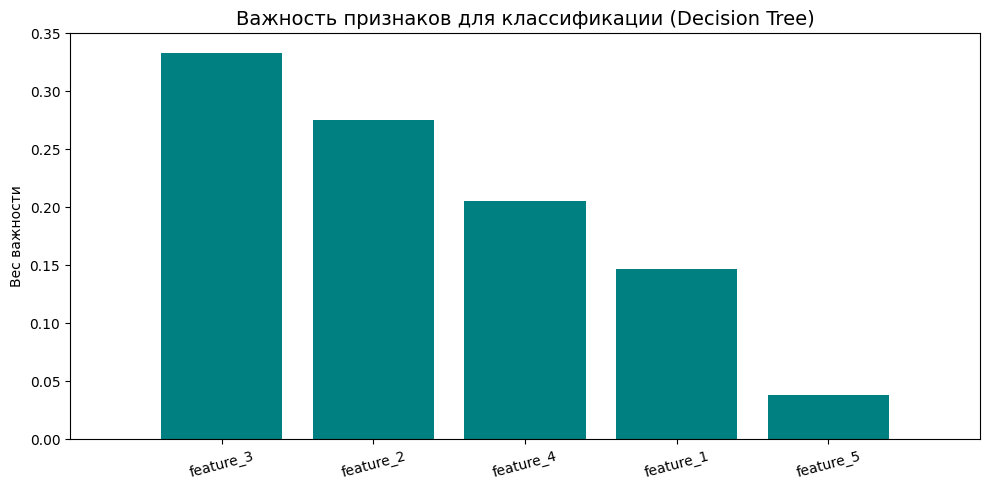

1. Признак 'feature_3': 0.3334
2. Признак 'feature_2': 0.2757
3. Признак 'feature_4': 0.2058
4. Признак 'feature_1': 0.1470
5. Признак 'feature_5': 0.0381


In [35]:
import numpy as np
import matplotlib.pyplot as plt

# Используем уже обученное дерево решений (tree_grid)
best_model = tree_grid.best_estimator_

if hasattr(best_model, 'named_steps'):
    # Если использовали Pipeline
    importances = best_model.named_steps['dt'].feature_importances_
else:
    # Если обучали модель напрямую
    importances = best_model.feature_importances_

indices = np.argsort(importances)[::-1]
features = X_train.columns

# Визуализация
plt.figure(figsize=(10, 5))
plt.title("Важность признаков для классификации (Decision Tree)", fontsize=14)
plt.bar(range(X_train.shape[1]), importances[indices], color="teal", align="center")
plt.xticks(range(X_train.shape[1]), [features[i] for i in indices], rotation=15)
plt.xlim([-1, X_train.shape[1]])
plt.ylabel("Вес важности")
plt.tight_layout()
plt.show()

# Текстовый вывод
for f in range(X_train.shape[1]):
    print(f"{f + 1}. Признак '{features[indices[f]]}': {importances[indices[f]]:.4f}")

### 18. Бустинг (CatBoost)

Ансамблевый алгоритм последовательного построения деревьев решений, где каждое новое дерево минимизирует ошибку (градиент функции потерь) предыдущей композиции.

*   **Плюсы:**
    *   Является самым мощным и точным алгоритмом для решения задач на структурированных табличных данных.
    *   Очень гибок за счет возможности настройки различных функций потерь (Loss Functions).
*   **Минусы:**
    *   Склонен к быстрому переобучению, если вовремя не остановить построение деревьев или неверно выбрать шаг обучения.
    *   Требует кропотливой и долгой настройки взаимозависимых гиперпараметров.
*   **Гиперпараметры:**
    *   `learning_rate` — темп обучения (шаг спуска). Малый шаг (например, `0.01`) требует большего числа деревьев (`n_estimators`), но делает модель более точной и устойчивой к переобучению.
    *   `n_estimators` — количество деревьев в ансамбле. Слишком большое значение ведет к переобучению.
    *   `max_depth` — глубина отдельных деревьев. Для бустинга обычно используют неглубокие деревья (от 3 до 6 уровней).
    *   `subsample` — доля объектов выборки, используемая для обучения конкретного дерева.

#### Обучение

In [36]:
import catboost as cb

cat = cb.CatBoostClassifier(
    iterations=500,
    learning_rate=0.1,
    max_depth=4,
    task_type='CPU',
    random_seed=RANDOM_SEED,
    verbose=False
)

cat.fit(X_train, y_train)

print("Train")
print(classification_report(y_train, cat.predict(X_train), digits=4))
print("\nTest")
print(classification_report(y_test, cat.predict(X_test), digits=4))

Train
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       107
           1     1.0000    1.0000    1.0000       107
           2     1.0000    1.0000    1.0000       106

    accuracy                         1.0000       320
   macro avg     1.0000    1.0000    1.0000       320
weighted avg     1.0000    1.0000    1.0000       320


Test
              precision    recall  f1-score   support

           0     0.8148    0.8148    0.8148        27
           1     0.8214    0.8519    0.8364        27
           2     0.8800    0.8462    0.8627        26

    accuracy                         0.8375        80
   macro avg     0.8387    0.8376    0.8380        80
weighted avg     0.8382    0.8375    0.8377        80



#### Поиск по сетке гиперпараметров

In [37]:
from typing import cast
from sklearn.base import BaseEstimator

cat_grid_params = {
    'iterations': [200, 500],
    'learning_rate': [0.03, 0.1],
    'depth': [1, 2, 3, 4],
    'l2_leaf_reg': [1, 3, 5]
}

cat_estimator = cast(
    BaseEstimator,
    cb.CatBoostClassifier(
        task_type='CPU',
        random_seed=RANDOM_SEED,
        verbose=True
    )
)

cat_search = GridSearchCV(
    estimator=cat_estimator,
    param_grid=cat_grid_params,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

cat_search.fit(X_train, y_train)

cat_train_pred = cat_search.predict(X_train)
cat_test_pred = cat_search.predict(X_test)

cat_acc_train = accuracy_score(y_train, cat_train_pred)
cat_acc_test = accuracy_score(y_test, cat_test_pred)

print(f"Лучшие параметры CatBoost: {cat_search.best_params_}")
print(f"Best CV accuracy: {cat_search.best_score_:.4f}")
print(f"Train accuracy: {cat_acc_train:.4f}")
print(f"Test accuracy: {cat_acc_test:.4f}")

0:	learn: 1.0422222	total: 984us	remaining: 491ms
1:	learn: 0.9876547	total: 1.78ms	remaining: 443ms
2:	learn: 0.9376546	total: 2.47ms	remaining: 410ms
3:	learn: 0.9128351	total: 3.21ms	remaining: 398ms
4:	learn: 0.8851050	total: 3.93ms	remaining: 389ms
5:	learn: 0.8573841	total: 4.74ms	remaining: 390ms
6:	learn: 0.8295375	total: 5.46ms	remaining: 385ms
7:	learn: 0.8025138	total: 6.96ms	remaining: 428ms
8:	learn: 0.7830553	total: 8.96ms	remaining: 489ms
9:	learn: 0.7643170	total: 9.79ms	remaining: 480ms
10:	learn: 0.7484282	total: 10.6ms	remaining: 471ms
11:	learn: 0.7214869	total: 11.5ms	remaining: 467ms
12:	learn: 0.7069853	total: 13.4ms	remaining: 501ms
13:	learn: 0.6940929	total: 14.1ms	remaining: 491ms
14:	learn: 0.6830762	total: 15.1ms	remaining: 487ms
15:	learn: 0.6673137	total: 15.7ms	remaining: 476ms
16:	learn: 0.6534139	total: 16.4ms	remaining: 467ms
17:	learn: 0.6414924	total: 17.2ms	remaining: 460ms
18:	learn: 0.6265542	total: 18ms	remaining: 455ms
19:	learn: 0.6165721	tota

In [38]:
# MLflow отчет для GridSearchCV (CatBoost)
mlflow.set_experiment("ML_2026_Search_Reports")

with mlflow.start_run(run_name="CatBoost_GridSearch"):
    mlflow.log_params({
        "model_type": "CatBoostClassifier",
        "search_type": "GridSearchCV",
        "train_size": len(y_train),
        "test_size": len(y_test),
        "features_n": X_train.shape[1]
    })

    mlflow.log_param("grid_search_params", str(cat_grid_params))
    mlflow.log_metrics({
        "acc_train": cat_acc_train,
        "acc_test": cat_acc_test,
        "best_cv_score": cat_search.best_score_
    })

    mlflow.sklearn.log_model(cat_search.best_estimator_, artifact_path="model")

2026/05/21 09:43:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/21 09:43:15 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/21 09:43:21 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


## Aнализ схожести предсказаний моделей

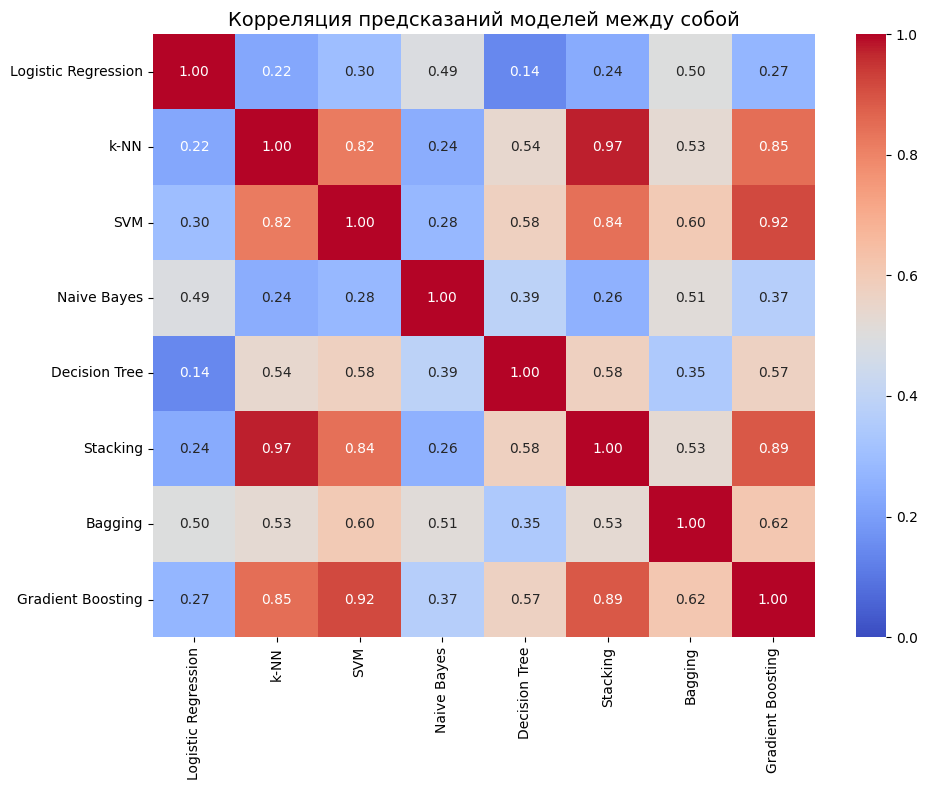

Вывод: Чем ниже корреляция между предсказаниями базовых моделей (при их высоком качестве),
тем эффективнее будет работать ансамбль Стекинга.


In [39]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Применяем .ravel(), чтобы привести все массивы предсказаний к одномерному виду
predictions_dict = {
    'Logistic Regression': lr_search.predict(X_test).ravel(),
    'k-NN': knn_grid.predict(X_test).ravel(),
    'SVM': svm_gs.predict(X_test).ravel(),
    'Naive Bayes': nb_search.predict(X_test).ravel(),
    'Decision Tree': tree_grid.predict(X_test).ravel(),
    'Stacking': stacking_model.predict(X_test).ravel(),
    'Bagging': bagging_model.predict(X_test).ravel(),
    'Gradient Boosting': cat_search.predict(X_test).ravel()
}

df_predictions = pd.DataFrame(predictions_dict)

# Строим корреляционную матрицу прогнозов
plt.figure(figsize=(10, 8))
sns.heatmap(df_predictions.corr(method='pearson'), annot=True, cmap='coolwarm', fmt=".2f", vmin=0, vmax=1)
plt.title("Корреляция предсказаний моделей между собой", fontsize=14)
plt.tight_layout()
plt.show()

print("Вывод: Чем ниже корреляция между предсказаниями базовых моделей (при их высоком качестве),")
print("тем эффективнее будет работать ансамбль Стекинга.")

## Итоговая сводная таблица результатов моделей

In [40]:
# ЯЧЕЙКА: Сводная таблица результатов всех моделей на тестовой выборке
from sklearn.metrics import accuracy_score, f1_score

results_list = []

# Словарь со всеми обученными моделями/сетками
all_models = {
    'Logistic Regression': lr_search,
    'k-NN': knn_grid,
    'SVM': svm,
    'Naive Bayes': nb_search,
    'Decision Tree': tree_grid,
    'Random Forest': rf_search,
    'Bagging': bagging_model,
    'Gradient Boosting': cat_search,
    'Stacking': stacking_model
}

for name, model in all_models.items():
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average='macro') # macro подходит для мультикласса
    
    results_list.append({
        'Модель': name,
        'Accuracy (Test)': round(acc, 4),
        'F1-Score Macro (Test)': round(f1, 4)
    })

# Создаем DataFrame и сортируем по F1-Score по убыванию
df_results = pd.DataFrame(results_list).sort_values(by='F1-Score Macro (Test)', ascending=False)

print("--- Сравнительная таблица эффективности моделей ---")
display(df_results)

--- Сравнительная таблица эффективности моделей ---


,Модель,Accuracy (Test),F1-Score Macro (Test)
8,Stacking,0.8625,0.8619
5,Random Forest,0.8500,0.8510
7,Gradient Boosting,0.8500,0.8508
1,k-NN,0.8500,0.8484
4,Decision Tree,0.7125,0.7156
6,Bagging,0.7125,0.7151
0,Logistic Regression,0.6375,0.6282
3,Naive Bayes,0.6000,0.5932
2,SVM,0.4125,0.3407


## Оценка важности признаков четырьмя способами

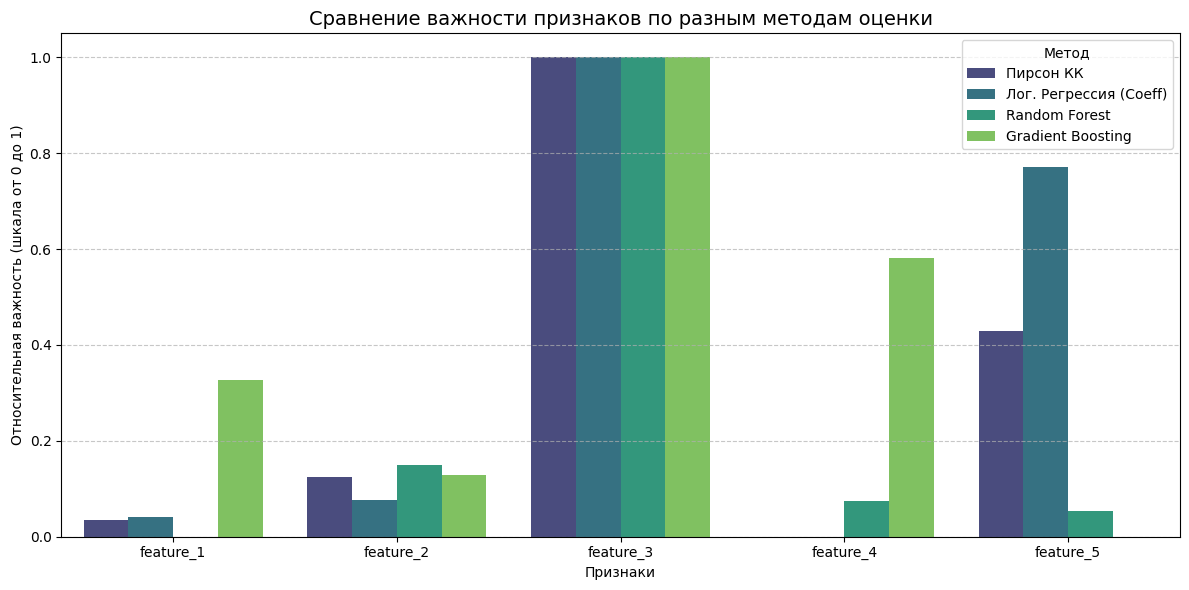

,Признак,Пирсон КК,Лог. Регрессия (Coeff),Random Forest,Gradient Boosting
0,feature_1,0.034257,0.041308,0.000000,0.327546
1,feature_2,0.124485,0.076408,0.149553,0.129353
2,feature_3,1.000000,1.000000,1.000000,1.000000
3,feature_4,0.000000,0.000000,0.073864,0.580556
4,feature_5,0.427988,0.770722,0.052593,0.000000


In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

features = X_train.columns
scaler_m = MinMaxScaler() # Используем для нормирования важностей в шкалу [0, 1]

# 1. Способ: КК Пирсона (абсолютные значения связи признаков с таргетом)
pearson_corr = np.abs(data.corr()['target'].drop('target').values)

# 2. Способ: Коэффициенты Логистической регрессии (прямой доступ без named_steps)
lr_coefs = np.mean(np.abs(lr_search.best_estimator_.coef_), axis=0)

# 3. Способ: Важность в Случайном лесе (Random Forest)
# Убедитесь, что rf_search уже обучен к этому моменту
rf_importances = rf_search.best_estimator_.feature_importances_

# 4. Способ: Важность в Градиентном бустинге (Gradient Boosting)
# Убедитесь, что cat_search уже обучен к этому моменту
gb_importances = cat_search.best_estimator_.feature_importances_

# Собираем данные в таблицу и нормируем в диапазон [0, 1] для наглядности сравнения
importance_df = pd.DataFrame({
    'Признак': features,
    'Пирсон КК': pearson_corr,
    'Лог. Регрессия (Coeff)': lr_coefs,
    'Random Forest': rf_importances,
    'Gradient Boosting': gb_importances
})

# Нормируем числовые столбцы
norm_cols = ['Пирсон КК', 'Лог. Регрессия (Coeff)', 'Random Forest', 'Gradient Boosting']
importance_df[norm_cols] = scaler_m.fit_transform(importance_df[norm_cols])

# Переводим в длинный формат для построения графиков seaborn
df_melted = importance_df.melt(id_vars='Признак', var_name='Метод', value_name='Относительная важность')

# Визуализация
plt.figure(figsize=(12, 6))
sns.barplot(data=df_melted, x='Признак', y='Относительная важность', hue='Метод', palette='viridis')
plt.title("Сравнение важности признаков по разным методам оценки", fontsize=14)
plt.ylabel("Относительная важность (шкала от 0 до 1)")
plt.xlabel("Признаки")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Вывод таблицы на экран
display(importance_df)